<a href="https://colab.research.google.com/github/floatbeyond/LAVIS/blob/main/projects/img2llm-vqa/img2llm_vqa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Img2Prompt-VQA: Inference Demo

In [1]:
# install requirements
import sys
if 'google.colab' in sys.modules:
    print('Running in Colab.')
    !pip install salesforce-lavis
    !pip install spacy
    !pip uninstall numpy -y
    !pip install numpy==1.26.0

Running in Colab.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 20.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.3/100.3 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.8/47.8 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.5 MB/s eta 0:00:00
   ━

### RESTART SESSION HERE!

### Load LLM to use

In [ ]:
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, AutoModelForSeq2SeqLM

def load_model(model_selection):
    model = AutoModelForCausalLM.from_pretrained(model_selection)
    tokenizer = AutoTokenizer.from_pretrained(model_selection, use_fast=False)
    return model,tokenizer

# Choose LLM to use
# weights for OPT-6.7B/OPT-13B/OPT-30B/OPT-66B will download automatically
print("Loading Large Language Model (LLM)...")
llm_model, tokenizer = load_model('facebook/opt-6.7b')  # ~13G (FP16)
# llm_model, tokenizer = load_model('facebook/opt-13b') # ~26G (FP16)
# llm_model, tokenizer = load_model('facebook/opt-30b') # ~60G (FP16)
# llm_model, tokenizer = load_model('facebook/opt-66b') # ~132G (FP16)

# you need to manually download weights, in order to use OPT-175B
# https://github.com/facebookresearch/metaseq/tree/main/projects/OPT
# llm_model, tokenizer = load_model('facebook/opt-175b')

Loading Large Language Model (LLM)...


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin.index.json:   0%|          | 0.00/41.9k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model-00001-of-00002.bin:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


pytorch_model-00002-of-00002.bin:   0%|          | 0.00/3.36G [00:00<?, ?B/s]

In [1]:
import torch
import requests
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np

from lavis.common.gradcam import getAttMap
from lavis.models import load_model_and_preprocess

/usr/local/lib/python3.11/dist-packages/fairscale/experimental/nn/offload.py:19: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_fwd(orig_func)  # type: ignore
/usr/local/lib/python3.11/dist-packages/fairscale/experimental/nn/offload.py:30: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  return torch.cuda.amp.custom_bwd(orig_func)  # type: ignore


In [2]:
# setup device to use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

### Load Img2Prompt-VQA model

In [3]:
model, vis_processors, txt_processors = load_model_and_preprocess(name="img2prompt_vqa", model_type="base", is_eval=True, device=device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


...

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/3.13G [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

100%|██████████| 2.92G/2.92G [03:26<00:00, 15.2MB/s]


### Load an example image and question

What are the white parts in the salad??


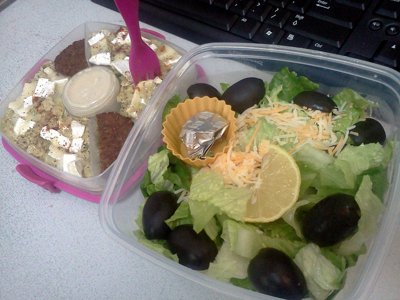

In [4]:
img_url = 'https://storage.googleapis.com/sfr-vision-language-research/LAVIS/projects/pnp-vqa/demo.png'
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert('RGB')

# raw_image = Image.open("./demo.png").convert("RGB")
question = "What are the white parts in the salad??"
print(question)
display(raw_image.resize((400, 300)))

### Preprocess image and text inputs

In [5]:
image = vis_processors["eval"](raw_image).unsqueeze(0).to(device)
question = txt_processors["eval"](question)

samples = {"image": image, "text_input": [question]}

### Img2Prompt-VQA utilizes 4 submodels to perform VQA:
#### 1. Image-Question Matching
Compute the relevancy score of image patches with respect to the question using GradCAM

In [6]:
samples = model.forward_itm(samples=samples)

Question: what are the white parts in the salad??


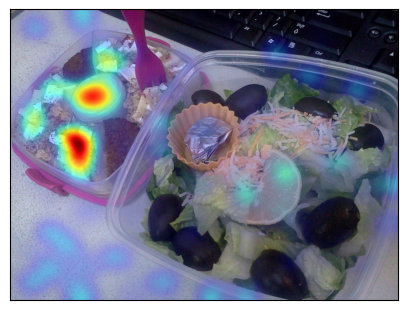

In [7]:
# Gradcam visualisation
dst_w = 720
w, h = raw_image.size
scaling_factor = dst_w / w

resized_img = raw_image.resize((int(w * scaling_factor), int(h * scaling_factor)))
norm_img = np.float32(resized_img) / 255
gradcam = samples['gradcams'].reshape(24,24).numpy()

avg_gradcam = getAttMap(norm_img, gradcam, blur=True)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(avg_gradcam)
ax.set_yticks([])
ax.set_xticks([])
print('Question: {}'.format(question))

#### 2. Image Captioning
Generate question-guided captions based on the relevancy score

In [8]:
samples = model.forward_cap(samples=samples, num_captions=10, num_patches=5)
print('Examples of question-guided captions: ')
samples['captions'][0][:5]

Examples of question-guided captions: 


['a lunch sitting on the couch, lemon and white cheese on the salad',
 'the bowl is holding a lemon and lemon slice in it are the same salad in',
 'a salad with foil wrappings wrapping foil',
 'spoon, utensils and fork with a pink table fork',
 'a, to lunch snack - lunch and sandwiches in']

#### 3. Question Generation
Generate synthetic questions using the captions

In [9]:
samples = model.forward_qa_generation(samples)
print('Sample Question: {} \nSample Answer: {}'.format(samples['questions'][:5], samples['answers'][:5]))

Sample Question: ['what is the bowl holding a lemon and lemon slice in it?', 'what is sitting on the couch?', 'what is on the white table topped with sauces and condiments?', 'what fruit is on the salad?', 'what is sitting between lemon wedges and cottage cheese?'] 
Sample Answer: ['salad.', 'lunch.', 'cheese.', 'lemon.', 'slice.']


In [10]:
samples['questions']

['what is the bowl holding a lemon and lemon slice in it?',
 'what is sitting on the couch?',
 'what is on the white table topped with sauces and condiments?',
 'what fruit is on the salad?',
 'what is sitting between lemon wedges and cottage cheese?',
 'what is wrapped around the salad?',
 'how is the lunch on the couch?',
 'what color cheese is on the salad?',
 'what is sitting on the couch?',
 'what is on the salad?',
 'what is used to eat the salad?',
 'what is topped with sauces and condiments?',
 'what is the snack on the couch?',
 'what is in the background?',
 'what is on the white table?',
 'what is on the white table?',
 'what type of cheese is on the salad?',
 'what is on the salad?',
 'what is in the salad with feta cheese, tofaro and pieces of what?',
 'how many pieces of tofu are in the salad?',
 'where is the lunch sitting?',
 'what is sitting on the couch?',
 'where is the lunch sitting?',
 'what is the bowl holding a lemon and lemon slice in it?',
 'what is holding a l

#### 4. Prompt Construction
Prepare the prompts for LLM

In [11]:
Img2Prompt = model.prompts_construction(samples)

#### 4. Load LLM and Predict Answers


In [12]:
# In this notebook, we only use CPU for LLM inference
# To run inference on GPU, see https://github.com/CR-Gjx/Img2Prompt for reference
device = "cpu"

def postprocess_Answer(text):
    for i, ans in enumerate(text):
        for j, w in enumerate(ans):
            if w == '.' or w == '\n':
                ans = ans[:j].lower()
                break
    return ans

Img2Prompt_input = tokenizer(Img2Prompt, padding='longest', truncation=True, return_tensors="pt").to(device)

assert (len(Img2Prompt_input.input_ids[0])+20) <=2048

outputs_list  = []
outputs = llm_model.generate(input_ids=Img2Prompt_input.input_ids,
                         attention_mask=Img2Prompt_input.attention_mask,
                         max_length=20+len(Img2Prompt_input.input_ids[0]),
                         return_dict_in_generate=True,
                         output_scores=True
                         )
outputs_list.append(outputs)


NameError: name 'tokenizer' is not defined

#### 5. Decoding to answers

In [ ]:
outputs_list

pred_answer = tokenizer.batch_decode(outputs.sequences[:, len(Img2Prompt_input.input_ids[0]):])
pred_answer = postprocess_Answer(pred_answer)

print({"question": question, "answer": pred_answer})